# <div align= "center" style="font-family: Verdana; font-weight:bold; color:#272829; font-size:150%; padding:10px; background:#F1EB90; border-radius: 10px">🤭 Emotion</div>

<p style="font-family: Verdana"> Emotions are feelings like happiness, love, fear, anger, or hatred. They can be caused by the situation you are in or the people you are with.</p>

In [1]:
import numpy as np 
import pandas as pd 
from collections import defaultdict 


import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from wordcloud import WordCloud, STOPWORDS

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

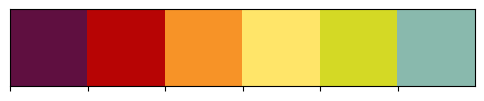

In [2]:
# custom color palette
my_colors = ["#5F0F40", "#B70404", "#F79327", "#FFE569", "#D4D925", "#89B9AD"]  

# Plot Color Palletes
sns.palplot(my_colors)

<div style="font-family: Verdana; font-weight:bold; letter-spacing: 0px; color:#272829; font-size:120%;">Loading dataset <br></div>

In [3]:
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test.csv')
validation_df = pd.read_csv('validation.csv')

In [4]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [5]:
import pandas as pd

<p style="font-family: Verdana;"> The dataset contains two columns 'text' and their corresponding 'label' </p>

In [6]:
train_df.shape

(16000, 2)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


# <div align="center" style="font-family: Verdana; font-weight:bold;color:#272829; font-size:150%; padding:10px; background:#F1EB90; border-radius: 10px">Exploratory data analysis </div>

In [9]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [10]:
train_df["label"].nunique()

6

In [11]:
labels_dict = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
train_df['label_name'] = train_df['label'].map(labels_dict)
train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [12]:
counts_values = train_df['label_name'].value_counts()
print(counts_values)

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_9104\3519043434.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=train_df["label_name"], palette= my_colors, order= counts_values.index)


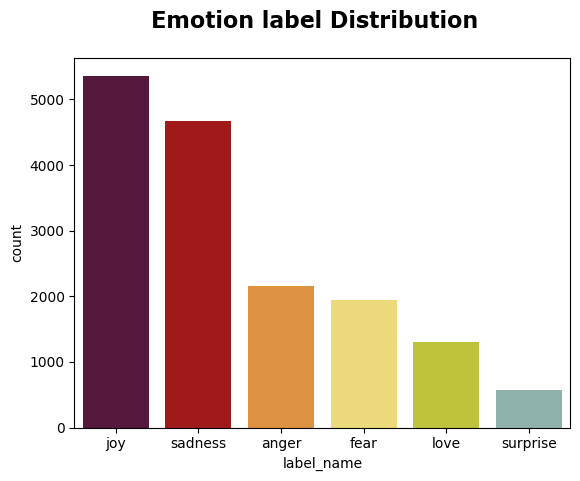

In [13]:
sns.countplot(data=train_df, x=train_df["label_name"], palette= my_colors, order= counts_values.index)
plt.suptitle('Emotion label Distribution', 
             fontweight = 'heavy', fontsize = 16, fontfamily = 'Verdana')
plt.show()

<b style="font-family: Verdana;"> The class labels are of uneven distribution with "joy" being the majority. </b>

In [14]:
train_df['text_length'] = train_df['text'].astype(str).apply(len)
train_df['text_word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))

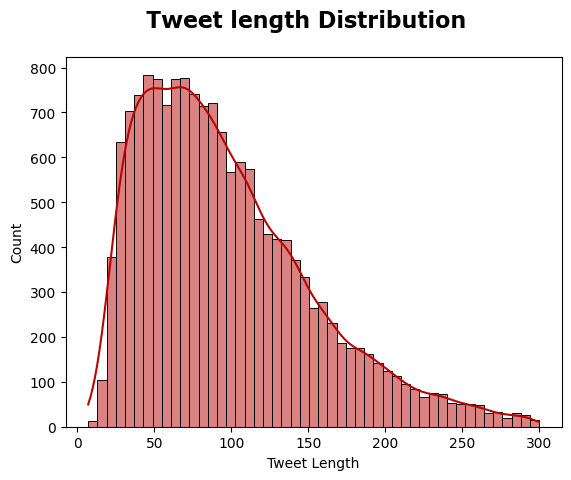

In [15]:
sns.histplot(train_df['text_length'], kde= 'True', color= my_colors[1])
plt.xlabel('Tweet Length')
plt.suptitle('Tweet length Distribution', 
             fontweight = 'heavy', fontsize = 16, fontfamily = 'Verdana')
plt.show()

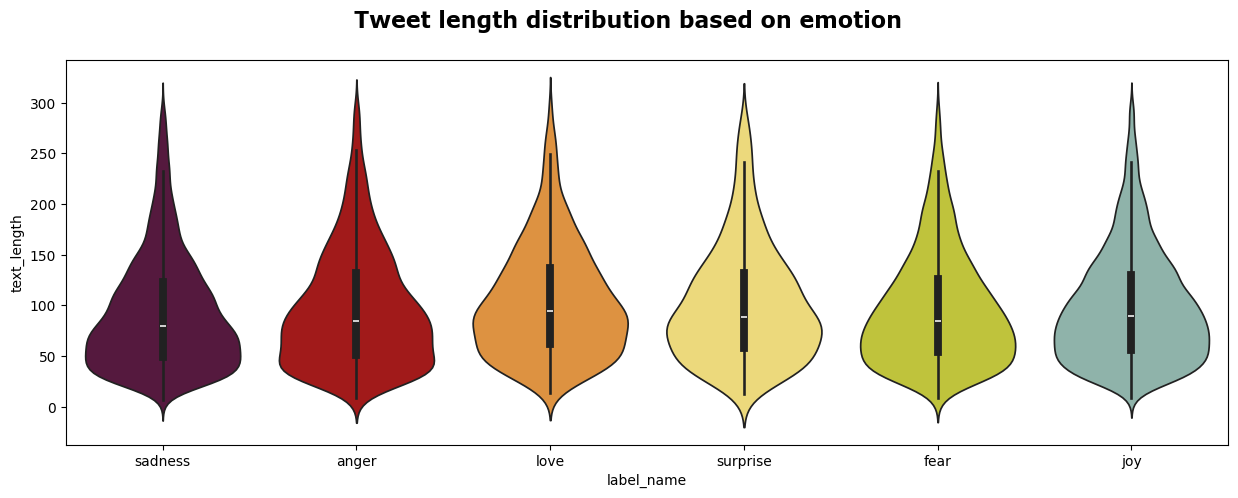

In [16]:

plt.figure(figsize=(15,5))
sns.violinplot(train_df,x='label_name', y='text_length',
       hue='label_name',
       palette= my_colors)
plt.suptitle('Tweet length distribution based on emotion', 
             fontweight = 'heavy', fontsize = 16, fontfamily = 'Verdana')
plt.show()

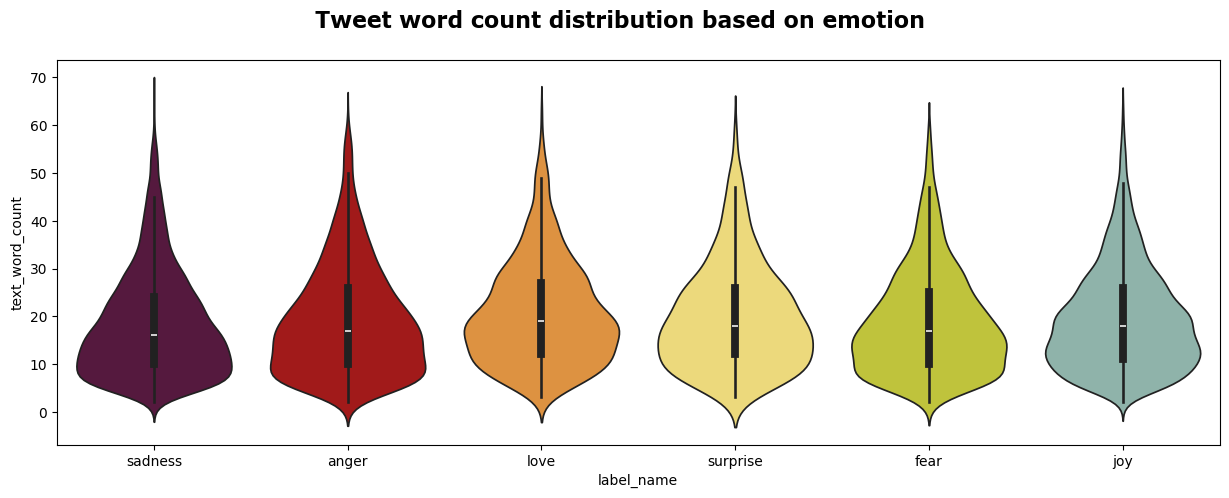

In [17]:
plt.figure(figsize=(15,5))
sns.violinplot(train_df,x='label_name', y='text_word_count',
       hue='label_name',
       palette= my_colors)
plt.suptitle('Tweet word count distribution based on emotion', 
             fontweight = 'heavy', fontsize = 16, fontfamily = 'Verdana')
plt.show()

# <div align="center" style="font-family: Verdana; font-weight:bold;color:#272829; font-size:150%; padding:10px; background:#F1EB90; border-radius: 10px">N-grams </div>

In [18]:
def generate_ngrams(text, n_gram=1):
    token = [token for token in text.lower().split(' ') if token != '' if token not in STOPWORDS]
    ngrams = zip(*[token[i:] for i in range(n_gram)])
    return [' '.join(ngram) for ngram in ngrams]

N = 30

sadness= train_df["label"]== 0
joy= train_df["label"]== 1
love= train_df["label"]== 2
anger = train_df["label"]== 3
fear = train_df["label"]== 4
surprise = train_df["label"]== 5

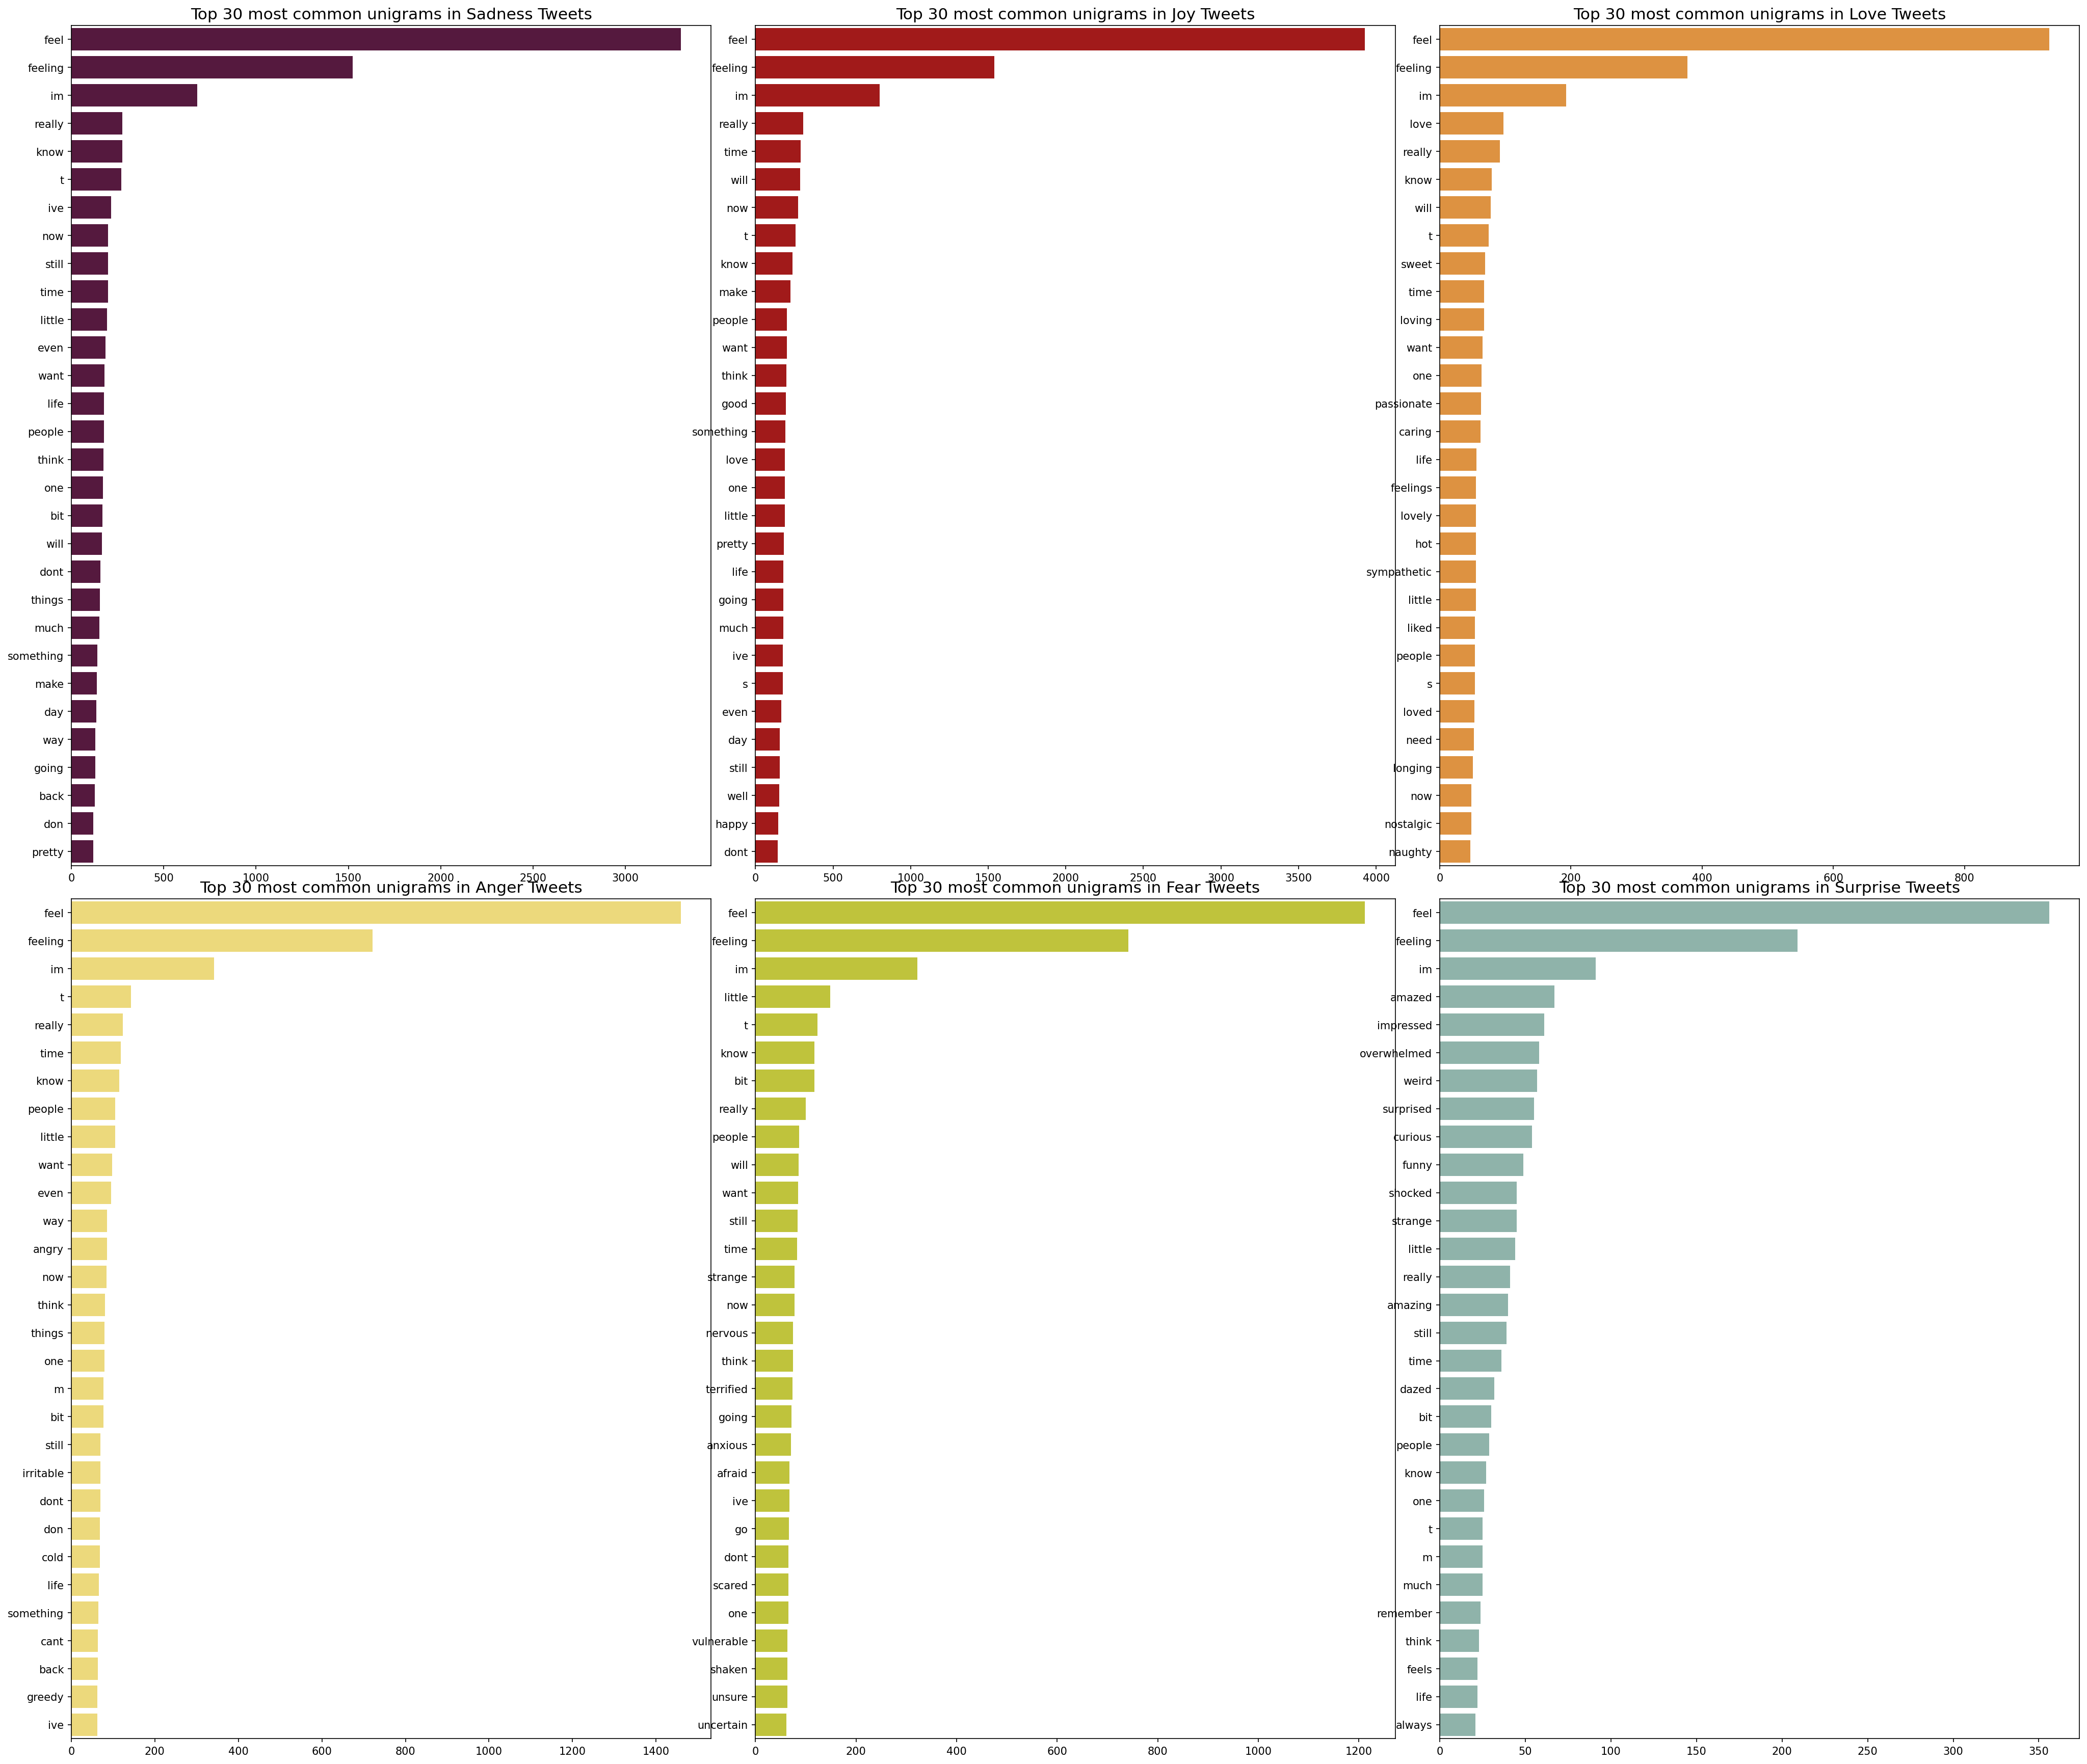

In [19]:
sadness_unigrams = defaultdict(int)
joy_unigrams = defaultdict(int)
love_unigrams = defaultdict(int)
anger_unigrams = defaultdict(int)
fear_unigrams = defaultdict(int)
surprise_unigrams = defaultdict(int)

# Unigrams
for tweet in train_df[sadness]['text']:
    for word in generate_ngrams(tweet):
        sadness_unigrams[word] += 1
        
for tweet in train_df[joy]['text']:
    for word in generate_ngrams(tweet):
        joy_unigrams[word] += 1
        
for tweet in train_df[love]['text']:
    for word in generate_ngrams(tweet):
        love_unigrams[word] += 1   

for tweet in train_df[anger]['text']:
    for word in generate_ngrams(tweet):
        anger_unigrams[word] += 1
        
for tweet in train_df[fear]['text']:
    for word in generate_ngrams(tweet):
        fear_unigrams[word] += 1
        
for tweet in train_df[surprise]['text']:
    for word in generate_ngrams(tweet):
        surprise_unigrams[word] += 1 
        
df_sadness_unigrams = pd.DataFrame(sorted(sadness_unigrams.items(), key=lambda x: x[1])[::-1])
df_joy_unigrams = pd.DataFrame(sorted(joy_unigrams.items(), key=lambda x: x[1])[::-1])
df_love_unigrams = pd.DataFrame(sorted(love_unigrams.items(), key=lambda x: x[1])[::-1])
df_anger_unigrams = pd.DataFrame(sorted(anger_unigrams.items(), key=lambda x: x[1])[::-1])
df_fear_unigrams = pd.DataFrame(sorted(fear_unigrams.items(), key=lambda x: x[1])[::-1])
df_surprise_unigrams = pd.DataFrame(sorted(surprise_unigrams.items(), key=lambda x: x[1])[::-1])


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(27, 23), dpi=150)
plt.tight_layout()

sns.barplot(y=df_sadness_unigrams[0].values[:N], x=df_sadness_unigrams[1].values[:N], ax=axes[0][0], color= my_colors[0])
sns.barplot(y=df_joy_unigrams[0].values[:N], x=df_joy_unigrams[1].values[:N], ax=axes[0][1], color= my_colors[1])
sns.barplot(y=df_love_unigrams[0].values[:N], x=df_love_unigrams[1].values[:N], ax=axes[0][2], color= my_colors[2])
sns.barplot(y=df_anger_unigrams[0].values[:N], x=df_anger_unigrams[1].values[:N], ax=axes[1][0], color= my_colors[3])
sns.barplot(y=df_fear_unigrams[0].values[:N], x=df_fear_unigrams[1].values[:N], ax=axes[1][1], color= my_colors[4])
sns.barplot(y=df_surprise_unigrams[0].values[:N], x=df_surprise_unigrams[1].values[:N], ax=axes[1][2], color= my_colors[5])


axes[0][0].set_title(f'Top {N} most common unigrams in Sadness Tweets', fontsize=15)
axes[0][1].set_title(f'Top {N} most common unigrams in Joy Tweets', fontsize=15)
axes[0][2].set_title(f'Top {N} most common unigrams in Love Tweets', fontsize=15)
axes[1][0].set_title(f'Top {N} most common unigrams in Anger Tweets', fontsize=15)
axes[1][1].set_title(f'Top {N} most common unigrams in Fear Tweets', fontsize=15)
axes[1][2].set_title(f'Top {N} most common unigrams in Surprise Tweets', fontsize=15)

plt.show()

In [20]:
# sadness_trigrams = defaultdict(int)
# joy_trigrams = defaultdict(int)
# love_trigrams = defaultdict(int)
# anger_trigrams = defaultdict(int)
# fear_trigrams = defaultdict(int)
# surprise_trigrams = defaultdict(int)

# # trigrams
# for tweet in train_df[sadness]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         sadness_trigrams[word] += 1
        
# for tweet in train_df[joy]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         joy_trigrams[word] += 1
        
# for tweet in train_df[love]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         love_trigrams[word] += 1   

# for tweet in train_df[anger]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         anger_trigrams[word] += 1
        
# for tweet in train_df[fear]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         fear_trigrams[word] += 1
        
# for tweet in train_df[surprise]['text']:
#     for word in generate_ngrams(tweet, n_gram=3):
#         surprise_trigrams[word] += 1 
        
# df_sadness_trigrams = pd.DataFrame(sorted(sadness_trigrams.items(), key=lambda x: x[1])[::-1])
# df_joy_trigrams = pd.DataFrame(sorted(joy_trigrams.items(), key=lambda x: x[1])[::-1])
# df_love_trigrams = pd.DataFrame(sorted(love_trigrams.items(), key=lambda x: x[1])[::-1])
# df_anger_trigrams = pd.DataFrame(sorted(anger_trigrams.items(), key=lambda x: x[1])[::-1])
# df_fear_trigrams = pd.DataFrame(sorted(fear_trigrams.items(), key=lambda x: x[1])[::-1])
# df_surprise_trigrams = pd.DataFrame(sorted(surprise_trigrams.items(), key=lambda x: x[1])[::-1])


# fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(27, 22), dpi=150)
# plt.tight_layout()

# sns.barplot(y=df_sadness_trigrams[0].values[:N], x=df_sadness_trigrams[1].values[:N], ax=axes[0][0], color= my_colors[0])
# sns.barplot(y=df_joy_trigrams[0].values[:N], x=df_joy_trigrams[1].values[:N], ax=axes[0][1], color= my_colors[1])
# sns.barplot(y=df_love_trigrams[0].values[:N], x=df_love_trigrams[1].values[:N], ax=axes[0][2], color= my_colors[2])
# sns.barplot(y=df_anger_trigrams[0].values[:N], x=df_anger_trigrams[1].values[:N], ax=axes[1][0], color= my_colors[3])
# sns.barplot(y=df_fear_trigrams[0].values[:N], x=df_fear_trigrams[1].values[:N], ax=axes[1][1], color= my_colors[4])
# sns.barplot(y=df_surprise_trigrams[0].values[:N], x=df_surprise_trigrams[1].values[:N], ax=axes[1][2], color= my_colors[5])


# axes[0][0].set_title(f'Top {N} most common trigrams in Sadness Tweets', fontsize=15)
# axes[0][1].set_title(f'Top {N} most common trigrams in Joy Tweets', fontsize=15)
# axes[0][2].set_title(f'Top {N} most common trigrams in Love Tweets', fontsize=15)
# axes[1][0].set_title(f'Top {N} most common trigrams in Anger Tweets', fontsize=15)
# axes[1][1].set_title(f'Top {N} most common trigrams in Fear Tweets', fontsize=15)
# axes[1][2].set_title(f'Top {N} most common trigrams in Surprise Tweets', fontsize=15)

# plt.show()

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# labels_dict = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}


In [22]:
train_df['label'].value_counts()


label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [23]:
import re
import string
import pandas as pd

import re
import string

def wordopt(text_list):
    cleaned_texts = []
    v=nltk.word_tokenize(text_list)
    for text in v:
        # print(text)
        text = text.lower()
        text = re.sub('\[.*?\]', '', text)
        text = re.sub("\\W", " ", text)
        text = re.sub('https?://\S+|www\.\S+', '', text)
        text = re.sub('<.*?>+', '', text)
        text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
        text = re.sub('\n', '', text)
        text = re.sub('\w*\d\w*', '', text)
        cleaned_texts.append(text)
    return cleaned_texts


In [24]:
train_df["text"]=train_df["text"].apply(wordopt)


In [25]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

lemmatizer = WordNetLemmatizer()
corpus = []

for index, row in train_df.iterrows():
    text_list = row['text']
    
    # Join the list of words into a single string
    text = ' '.join(text_list)

    # Remove non-alphabetic characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Split the words
    text = text.split()

    # Lemmatize and remove stopwords
    text = [lemmatizer.lemmatize(word) for word in text if word not in set(stopwords.words('english'))]

    # Join the lemmatized words into a single string
    text = ' '.join(text)

    # Append the processed text to the corpus
    corpus.append(text)

# Assign the processed corpus back to the "Comments" column
train_df["text"] = corpus


In [26]:
train_df

,text,label,label_name,text_length,text_word_count
0,didnt feel humiliated,0,sadness,23,4
1,go feeling hopeless damned hopeful around some...,0,sadness,108,21
2,im grabbing minute post feel greedy wrong,3,anger,48,10
3,ever feeling nostalgic fireplace know still pr...,2,love,92,18
4,feeling grouchy,3,anger,20,4
...,...,...,...,...,...
15995,brief time beanbag said anna feel like beaten,0,sadness,101,24
15996,turning feel pathetic still waiting table subb...,0,sadness,102,20
15997,feel strong good overall,1,joy,30,6
15998,feel like rude comment im glad,3,anger,59,14


In [27]:
# train_df.to_csv('clean_emotion.csv',index=False)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [29]:
# Converting the Words to Vector using Bag of words
from sklearn.feature_extraction.text import TfidfVectorizer
cv=TfidfVectorizer(max_features=2500,ngram_range=(1,3)) # top 2500 features are taken 
X=cv.fit_transform(corpus).toarray()
y=train_df['label']

In [30]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=1,stratify=y)

In [31]:
y.value_counts()

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [32]:
y_train.value_counts()

label
1    4290
0    3733
3    1727
4    1550
2    1043
5     457
Name: count, dtype: int64

## Naive Bayes

In [33]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(x_train,y_train)

print('*'*20)
train_pred=nb.predict(x_train)
test_pred=nb.predict(x_test)
print('*'*20)
from sklearn.metrics import classification_report,accuracy_score,f1_score,recall_score,precision_score

# Calculate metrics
accuracy = accuracy_score(y_test, test_pred)
f1score = f1_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None
precision = precision_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None
recall = recall_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None

# Print metrics
print("Accuracy: ", accuracy)
print("F1 Score: ", f1score)
print("Precision: ", precision)
print("Recall: ", recall)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, test_pred))


********************
********************
Accuracy:  0.8021875
F1 Score:  0.7805833731743682
Precision:  0.8246474604957668
Recall:  0.8021875
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.94      0.87       933
           1       0.74      0.97      0.84      1072
           2       0.92      0.32      0.48       261
           3       0.91      0.69      0.78       432
           4       0.88      0.64      0.74       387
           5       0.95      0.16      0.27       115

    accuracy                           0.80      3200
   macro avg       0.87      0.62      0.66      3200
weighted avg       0.82      0.80      0.78      3200



## support vector

In [34]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(x_train,y_train)

print('*'*20)

#prediction
test_pred=svm.predict(x_test)

print('*'*20)
from sklearn.metrics import classification_report,accuracy_score,f1_score,recall_score,precision_score

# Calculate metrics Evaluation
accuracy = accuracy_score(y_test, test_pred)
f1score = f1_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None
precision = precision_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None
recall = recall_score(y_test, test_pred, average='weighted')  # or average='macro', 'micro', or None

# Print metrics
print("Accuracy: ", accuracy)
print("F1 Score: ", f1score)
print("Precision: ", precision)
print("Recall: ", recall)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, test_pred))


********************
********************
Accuracy:  0.863125
F1 Score:  0.857616765262402
Precision:  0.8659436943025731
Recall:  0.863125
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       933
           1       0.83      0.96      0.89      1072
           2       0.88      0.58      0.70       261
           3       0.89      0.79      0.84       432
           4       0.87      0.77      0.82       387
           5       0.88      0.52      0.66       115

    accuracy                           0.86      3200
   macro avg       0.87      0.76      0.80      3200
weighted avg       0.87      0.86      0.86      3200



## random forest 

In [35]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)

print('*'*20)
train_pred=rfc.predict(x_train)

test_pred=rfc.predict(x_test)

print('*'*20)
from sklearn.metrics import accuracy_score

acc=accuracy_score(y_test,test_pred)
print(acc)
print('*'*20)
print(classification_report(test_pred,y_test))

********************
********************
0.87125
********************
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       938
           1       0.90      0.89      0.90      1088
           2       0.72      0.82      0.76       228
           3       0.87      0.84      0.85       450
           4       0.82      0.82      0.82       389
           5       0.70      0.76      0.73       107

    accuracy                           0.87      3200
   macro avg       0.82      0.84      0.83      3200
weighted avg       0.87      0.87      0.87      3200



## decision tree classification

In [36]:
# modeling
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

print('*'*20)
# prediction

test_prediction = dtc.predict(x_test)
train_prediction = dtc.predict(x_train)

#evaluation

print('*'*20)
from sklearn.metrics import accuracy_score, confusion_matrix

print('train_accuracy',accuracy_score(y_train,train_prediction))

print('test_accuracy',accuracy_score(y_test,test_prediction))

print('*'*20)
print(classification_report(y_test,test_prediction))

********************
********************
train_accuracy 0.99734375
test_accuracy 0.850625
********************
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       933
           1       0.88      0.86      0.87      1072
           2       0.79      0.78      0.78       261
           3       0.82      0.85      0.83       432
           4       0.80      0.81      0.80       387
           5       0.77      0.65      0.71       115

    accuracy                           0.85      3200
   macro avg       0.82      0.81      0.81      3200
weighted avg       0.85      0.85      0.85      3200



## voting classifier

In [37]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Create Model with configuration
eclf1 = VotingClassifier(estimators=[
    ('Decision', dtc),
    ('Random', rfc),
    ('nb',nb )
], 
weights=[1, 1, 1],
flatten_transform=True)

# Assuming you have X_train, X_test, y_train, y_test initialized
eclf1 = eclf1.fit(x_train, y_train) 

# Prediction
test_prediction = eclf1.predict(x_test) 
train_prediction = eclf1.predict(x_train) 

# Evaluation
print('test accuracy:', accuracy_score(y_test, test_prediction))
print('train accuracy:', accuracy_score(y_train, train_prediction))

print('*' * 20)

# Prediction Summary by species
print(classification_report(y_test, test_prediction))
print('*' * 20)

# Accuracy score
voting = accuracy_score(test_prediction, y_test)
print(f"{round(voting * 100, 2)}% Accurate")


test accuracy: 0.8690625
train accuracy: 0.997265625
********************
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       933
           1       0.89      0.91      0.90      1072
           2       0.84      0.70      0.76       261
           3       0.85      0.86      0.85       432
           4       0.84      0.80      0.82       387
           5       0.82      0.64      0.72       115

    accuracy                           0.87      3200
   macro avg       0.85      0.81      0.83      3200
weighted avg       0.87      0.87      0.87      3200

********************
86.91% Accurate


## light gbm

In [38]:
# Import libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix, and y is your target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Define parameters for multiclass classification
params = {
    'objective': 'multiclass',
    'num_class': len(set(y_train)),  # Number of unique classes in the target variable
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

num_round = 100
model1 = lgb.train(params, train_data, num_round, valid_sets=[test_data])

# Make predictions for multiclass
y_pred = model1.predict(X_test, num_iteration=model1.best_iteration)
lbgm_pred_class = [pred.argmax() for pred in y_pred]  # Predicted class is the one with the highest probability

# Evaluate the model
accuracy1 = accuracy_score(y_test, lbgm_pred_class)
print(f"Accuracy: {accuracy1}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, lbgm_pred_class))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056237 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 29044
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 1255
[LightGBM] [Info] Start training from score -1.235722
[LightGBM] [Info] Start training from score -1.081340
[LightGBM] [Info] Start training from score -2.541477
[LightGBM] [Info] Start training from score -2.000168
[LightGBM] [Info] Start training from score -2.117663
[LightGBM] [Info] Start training from score -3.328150
Accuracy: 0.8621875

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       946
           1       0.81      0.93      0.87      1021
           2       0.83      0.79      0.81       296
           3       0.87      0.78      0.82       427
     

## comparing graphs

In [39]:
score = [85.12,87.93,80.21,86.59,86.31,86.21]
Models = pd.DataFrame({
    'Model': ["Decision Tree","Random Forest",'MultinomialNB','Voting clssifier',"SVM","Lightbgm"],
    'Score': score})
Models.sort_values(by='Score', ascending=False)

,Model,Score
1,Random Forest,87.93
3,Voting clssifier,86.59
4,SVM,86.31
5,Lightbgm,86.21
0,Decision Tree,85.12
2,MultinomialNB,80.21


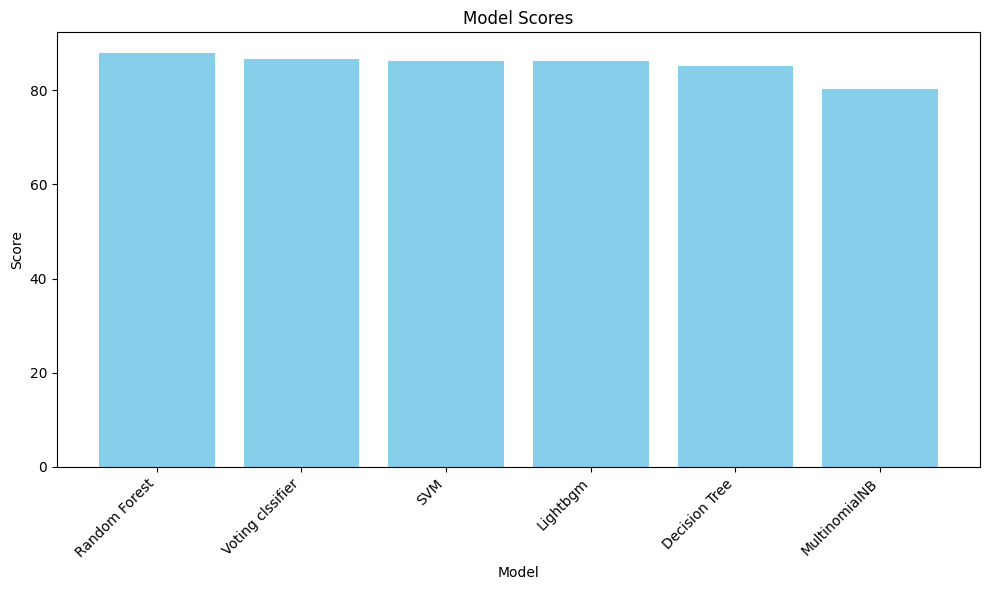

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming score and Models are already defined as per your code

# Create a DataFrame
Models = pd.DataFrame({
    'Model': ["Decision Tree","Random Forest",'MultinomialNB','Voting clssifier',"SVM","Lightbgm"],
    'Score': score
})

# Sort the DataFrame by 'Score' in descending order
Models_sorted = Models.sort_values(by='Score', ascending=False)

# Plotting the bar graph
plt.figure(figsize=(10, 6))
plt.bar(Models_sorted['Model'], Models_sorted['Score'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Scores')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()


In [41]:
import pickle
filename = 'vectorizer.pkl'
pickle.dump(cv, open(filename, 'wb'))

In [42]:
import pickle

filename = 'rf_yt.pkl'
pickle.dump(rfc, open(filename, 'wb'))

In [43]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[0]


In [44]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[0]


In [45]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[0]


In [46]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[5]


In [47]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[5]


In [48]:
import re
from nltk.stem import WordNetLemmatizer
import pickle

# Load vectorizer and model
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
mnb = pickle.load(open('rf_yt.pkl','rb'))

strr = input('Enter Your Message: ')
print("-------------------------------")
example_counts = vectorizer.transform([strr])
prediction = mnb.predict(example_counts)
print(prediction)


-------------------------------
[5]


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from transformers import AlbertTokenizer, AlbertModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Embedding, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Load the Amazon review dataset
dataset_path = 'clean_emotion.csv'
df = pd.read_csv(dataset_path)

# Preprocess the data
max_len = 256
albert_tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')

# Tokenize and pad sequences
sequences = [albert_tokenizer.encode(text, max_length=max_len, truncation=True, padding='max_length') for text in df['text']]
padded_sequences = np.array(sequences)

labels = np.array(df['label'])

# Convert labels to categorical for multiclass classification
y_train = to_categorical(labels, num_classes=6)

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(padded_sequences, y_train, test_size=0.2, random_state=42)

# Build the model
embedding_dim = 128

model = Sequential()
model.add(Embedding(input_dim=albert_tokenizer.vocab_size, output_dim=embedding_dim))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(6, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate on the test set
y_pred = np.argmax(model.predict(x_test), axis=-1)

# Calculate metrics
accuracy = accuracy_score(np.argmax(y_test, axis=-1), y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(np.argmax(y_test, axis=-1), y_pred, average='weighted')

# Print metrics
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
